<a href="https://colab.research.google.com/github/nova888/Data-Science/blob/master/Taxpayer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset

In [1]:
import pandas as pd
import numpy as np
import random

np.random.seed(42)

n = 50

# Distribusi log-normal
omzet_numeric = np.random.lognormal(mean=18, sigma=1, size=n)
aset_numeric = omzet_numeric * np.random.uniform(0.5, 2.5, size=n)
pegawai_numeric = np.clip((omzet_numeric / 1e8) + np.random.normal(0, 1, n), 1, 15)

def format_omzet(x):
    choice = random.choice(['normal', 'kurang', 'tidak'])
    if choice == 'tidak':
        return 'tidak ada'
    elif choice == 'kurang':
        return f"Kurang dari {int(x):,}".replace(",", ".")
    else:
        return f"{int(x):,}".replace(",", ".")

def format_aset(x):
    if random.random() > 0.7:
        return f"{int(x/1e6)} jt"
    elif random.random() > 0.5:
        return f"{int(x/1e6)} juta"
    else:
        return f"{int(x)}"

def format_pegawai(x):
    choice = random.choice(['org', 'range', 'plain'])
    if choice == 'org':
        return f"{int(x)} org"
    elif choice == 'range':
        return f"{int(x)}-{int(x)+1}"
    else:
        return str(int(x))

data = {
    'Berapa rata-rata omzet (pendapatan kotor) usaha Anda dalam 1 tahun terakhir? (nominal, cth; 100.000.000)': [
        format_omzet(x) for x in omzet_numeric
    ],

    'Berapa jumlah total pegawai tetap dan tidak tetap saat ini?': [
        format_pegawai(x) for x in pegawai_numeric
    ],

    'Berapa nilai total aset usaha Anda (tidak termasuk tanah dan bangunan tempat usaha)?': [
        format_aset(x) for x in aset_numeric
    ],
}

# behavior pajak

npwp = []
spt_selalu = []
spt_kadang = []
tidak_pernah = []
belum_kena = []
sesekali = []
pernah = []
sering = []

for i in range(n):
    prob_patuh = min(0.9, omzet_numeric[i] / omzet_numeric.max())

    has_npwp = random.random() < prob_patuh
    npwp.append(1 if has_npwp else np.nan)

    if has_npwp:
        spt_selalu.append(1 if random.random() < prob_patuh else np.nan)
        spt_kadang.append(1 if random.random() < 0.3 else np.nan)
    else:
        spt_selalu.append(np.nan)
        spt_kadang.append(np.nan)

    # Riwayat pajak
    if prob_patuh > 0.7:
        tidak_pernah.append(1)
        belum_kena.append(np.nan)
        sesekali.append(np.nan)
        pernah.append(np.nan)
        sering.append(np.nan)
    elif prob_patuh > 0.4:
        tidak_pernah.append(np.nan)
        belum_kena.append(1)
        sesekali.append(np.nan)
        pernah.append(np.nan)
        sering.append(np.nan)
    else:
        tidak_pernah.append(np.nan)
        belum_kena.append(np.nan)
        sesekali.append(1 if random.random() > 0.5 else np.nan)
        pernah.append(1 if random.random() > 0.7 else np.nan)
        sering.append(1 if random.random() > 0.8 else np.nan)

data.update({
    'Apakah usaha Anda memiliki NPWP?: Ya': npwp,
    'Apakah Anda melaporkan SPT Tahunan secara rutin?: Selalu': spt_selalu,
    'Apakah Anda melaporkan SPT Tahunan secara rutin?: Kadang-kadang': spt_kadang,
    'Apakah Anda pernah telat atau tidak membayar pajak yang seharusnya?: Tidak Pernah': tidak_pernah,
    'Apakah Anda pernah telat atau tidak membayar pajak yang seharusnya?: Belum Kena Pajak': belum_kena,
    'Apakah Anda pernah telat atau tidak membayar pajak yang seharusnya?: Sesekali': sesekali,
    'Apakah Anda pernah telat atau tidak membayar pajak yang seharusnya?: Pernah': pernah,
    'Apakah Anda pernah telat atau tidak membayar pajak yang seharusnya?: Sering': sering,
})

df_dummy = pd.DataFrame(data)
df_dummy.to_excel("Data.xlsx", index=False)

In [2]:
import random

nama_umkm = [
    "Warung Maju Jaya", "Toko Berkah", "Dapur Nusantara",
    "Kopi Santai", "Bengkel Mandiri", "Laundry Express",
    "Sablon Kreatif", "Tani Makmur"
]

def rand_choice(lst): return random.choice(lst)

data_tambahan = {
    'Nama UMKM': [rand_choice(nama_umkm) for _ in range(10)],

    'Omzet_Raw': [
        rand_choice(['10 jt','50 juta','100000000','tidak ada','75 jt'])
        for _ in range(10)
    ],

    'Pegawai_Raw': [
        rand_choice(['1','2 org','3 orang','1-2','5'])
        for _ in range(10)
    ],

    'Aset_Raw': [
        rand_choice(['5 jt','20 juta','100000000','tidak ada','50 jt'])
        for _ in range(10)
    ],

    'Jenis_Usaha': [
        rand_choice(['Kuliner','Jasa','Manufaktur','Retail'])
        for _ in range(10)
    ],

    'NPWP': [
        rand_choice(['Ya','Tidak'])
        for _ in range(10)
    ],

    'SPT': [
        rand_choice(['Selalu','Kadang-kadang','Tidak Pernah'])
        for _ in range(10)
    ],

    'Telat_Pajak': [
        rand_choice(['Tidak Pernah','Belum Capai Limit','Sesekali','Pernah','Sering'])
        for _ in range(10)
    ]
}

df_add = pd.DataFrame(data_tambahan)

# PREPROCESSING

In [3]:
# PREPROCESSING

import pandas as pd
import numpy as np
import re

# Load data
df = pd.read_excel("Data.xlsx")

# CLEANING FUNCTIONS

def clean_omzet(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    if 'tidak ada' in value:
        return 0.0

    if 'kurang dari' in value:
        number = re.findall(r'\d+', value.replace('.', ''))
        return float(number[0]) if number else np.nan

    number = re.sub(r'[^0-9]', '', value)
    return float(number) if number != '' else np.nan


def clean_aset(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    if 'tidak ada' in value:
        return 0.0

    if 'juta' in value or 'jt' in value:
        number = re.findall(r'\d+', value)
        return float(number[0]) * 1_000_000 if number else np.nan

    number = re.sub(r'[^0-9]', '', value)
    return float(number) if number != '' else np.nan


def clean_pegawai(x):
    if pd.isna(x):
        return np.nan
    nums = re.findall(r'\d+', str(x))
    return float(nums[0]) if nums else np.nan

In [5]:
# APPLY CLEANING

df['Omzet_Bersih'] = df['Berapa rata-rata omzet (pendapatan kotor) usaha Anda dalam 1 tahun terakhir? (nominal, cth; 100.000.000)'].apply(clean_omzet)

df['Jumlah_Pegawai'] = df['Berapa jumlah total pegawai tetap dan tidak tetap saat ini?'].apply(clean_pegawai)

df['Aset_Bersih'] = df['Berapa nilai total aset usaha Anda (tidak termasuk tanah dan bangunan tempat usaha)?'].apply(clean_aset)

# SKOR KEPATUHAN

In [6]:
df['Skor_Kepatuhan'] = 0

# NPWP
df.loc[df['Apakah usaha Anda memiliki NPWP?: Ya'].notna(), 'Skor_Kepatuhan'] += 30

# SPT
df.loc[df['Apakah Anda melaporkan SPT Tahunan secara rutin?: Selalu'].notna(), 'Skor_Kepatuhan'] += 40
df.loc[df['Apakah Anda melaporkan SPT Tahunan secara rutin?: Kadang-kadang'].notna(), 'Skor_Kepatuhan'] += 15

# Riwayat Pajak
df.loc[df['Apakah Anda pernah telat atau tidak membayar pajak yang seharusnya?: Tidak Pernah'].notna(), 'Skor_Kepatuhan'] += 30
df.loc[df['Apakah Anda pernah telat atau tidak membayar pajak yang seharusnya?: Belum Kena Pajak'].notna(), 'Skor_Kepatuhan'] += 30

df.loc[df['Apakah Anda pernah telat atau tidak membayar pajak yang seharusnya?: Sesekali'].notna(), 'Skor_Kepatuhan'] += 10
df.loc[df['Apakah Anda pernah telat atau tidak membayar pajak yang seharusnya?: Pernah'].notna(), 'Skor_Kepatuhan'] += 5
df.loc[df['Apakah Anda pernah telat atau tidak membayar pajak yang seharusnya?: Sering'].notna(), 'Skor_Kepatuhan'] += 0

# FEATURE SELECTION

In [7]:
X = df[['Omzet_Bersih', 'Jumlah_Pegawai', 'Aset_Bersih', 'Skor_Kepatuhan']].fillna(0)

# Drop index sesuai pipeline kamu
X = X.drop([1, 11, 14, 29], errors='ignore')
df = df.drop([1, 11, 14, 29], errors='ignore')

df = df[['Omzet_Bersih', 'Jumlah_Pegawai', 'Aset_Bersih', 'Skor_Kepatuhan']].fillna(0)

In [8]:
# SCALING

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ELBOW METHOD

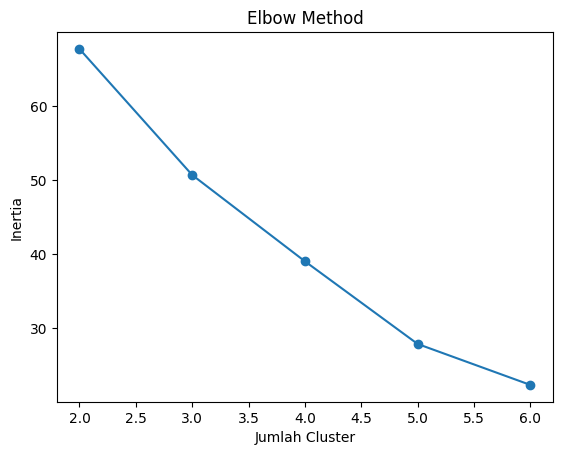

In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [10]:
# SILHOUETTE SCORE

from sklearn.metrics import silhouette_score

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.729
k=3, silhouette=0.688
k=4, silhouette=0.553
k=5, silhouette=0.396


# FINAL CLUSTER

In [11]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
# CLUSTER PROFILE

cluster_profile = df.groupby('Cluster')[[
    'Omzet_Bersih',
    'Jumlah_Pegawai',
    'Aset_Bersih',
    'Skor_Kepatuhan'
]].mean()

print(cluster_profile)

         Omzet_Bersih  Jumlah_Pegawai   Aset_Bersih  Skor_Kepatuhan
Cluster                                                            
0        3.022983e+08        3.000000  4.858307e+08       61.000000
1        4.230435e+07        1.121951  7.858985e+07       14.390244


In [12]:
cluster_labels = {
    0: 'UMKM Skala Rendah & Kepatuhan Rendah',
    1: 'UMKM Berkembang & Lebih Patuh'
}

df['Nama_Cluster'] = df['Cluster'].map(cluster_labels)

In [13]:
cluster_profile = df.groupby('Nama_Cluster')[[
    'Omzet_Bersih',
    'Jumlah_Pegawai',
    'Aset_Bersih',
    'Skor_Kepatuhan'
]].mean()

cluster_profile

,Omzet_Bersih,Jumlah_Pegawai,Aset_Bersih,Skor_Kepatuhan
Nama_Cluster,,,,
UMKM Berkembang & Lebih Patuh,1.930411e+08,3.200000,4.816000e+08,78.000000
UMKM Skala Rendah & Kepatuhan Rendah,4.206977e+07,1.097561,7.914748e+07,8.170732


| Cluster | Omzet    | Pegawai | Aset     | Skor Kepatuhan |
| ------- | -------- | ------- | -------- | -------------- |
| A       | 42 juta  | 1.1     | 78 juta  | **14**         |
| B       | 302 juta | 3       | 485 juta | **61**         |


* Cluster A = kecil + tidak patuh
* Cluster B = besar + lebih patuh


# INTERPRETASI

### **Cluster 1: UMKM Skala Rendah & Kepatuhan Rendah**

Kelompok ini ditandai dengan:

* Rata-rata omzet relatif rendah (~42 juta/tahun)
* Jumlah tenaga kerja sangat minimal (~1 orang)
* Nilai aset usaha terbatas (~78 juta)
* Skor kepatuhan pajak sangat rendah (~14)

Interpretasi:

Kelompok ini merepresentasikan **UMKM mikro dengan tingkat informalitas yang tinggi**. Rendahnya kepatuhan pajak mengindikasikan bahwa sebagian besar pelaku usaha dalam cluster ini:

* belum memiliki NPWP,
* tidak melaporkan SPT secara rutin,
* atau belum memahami kewajiban perpajakan.

Secara struktural, kondisi ini dapat disebabkan oleh:

* keterbatasan literasi perpajakan,
* skala usaha yang masih subsisten,
* serta persepsi bahwa usaha belum wajib dikenakan pajak.

---

### **Cluster 2: UMKM Berkembang & Lebih Patuh**

Kelompok ini memiliki karakteristik:

* Rata-rata omzet lebih tinggi (~302 juta/tahun)
* Jumlah tenaga kerja lebih banyak (~3 orang)
* Nilai aset signifikan (~485 juta)
* Skor kepatuhan pajak lebih tinggi (~61)

Interpretasi:

Cluster ini mencerminkan **UMKM yang berada pada fase pertumbuhan (growing stage)** dengan tingkat formalitas yang lebih baik. Tingginya skor kepatuhan menunjukkan bahwa pelaku usaha dalam kelompok ini:

* cenderung telah memiliki NPWP,
* lebih rutin dalam pelaporan SPT,
* serta memiliki kesadaran administrasi yang lebih baik.

Hal ini mengindikasikan adanya hubungan positif antara:

> **skala usaha dan tingkat kepatuhan pajak**

---

# KEY INSIGHT

> **Semakin besar skala usaha, semakin tinggi tingkat kepatuhan pajak UMKM.**

Ini bukan kebetulan, tapi fenomena umum karena:

* UMKM besar lebih terekspos sistem formal
* lebih butuh legalitas (bank, investor, dll)
* lebih aware terhadap risiko pajak

---

# KRITIK ANALITIS

Walaupun terlihat ada hubungan positif, perlu dicatat:

* Skor kepatuhan cluster besar masih **belum maksimal (61/100)**
* Artinya:

  > bahkan UMKM yang sudah berkembang pun masih belum sepenuhnya patuh

Membuka ruang kebijakan:

* edukasi pajak lanjutan
* simplifikasi sistem pelaporan

---

> Hasil clustering menunjukkan adanya dua kelompok utama UMKM, yaitu UMKM skala rendah dengan tingkat kepatuhan pajak yang rendah, serta UMKM yang lebih berkembang dengan tingkat kepatuhan yang relatif lebih tinggi. Temuan ini mengindikasikan adanya hubungan positif antara skala usaha dan kepatuhan pajak, meskipun tingkat kepatuhan pada kelompok usaha berkembang masih belum optimal.

---


> **evidence empiris sederhana tentang tax compliance behavior di UMKM**